In [95]:
import numpy as np
import scipy.signal as ss
import matplotlib.pyplot as plt

from src.pybf.pybf.transducer import Transducer
from src.bitstream_parser import parse_bitstream_jax, parse_bitstream
from src.pybf.scripts.beamformer_cartesian_realtime import BFCartesianRealTime
from src.pybf.pybf.visualization import plot_image

from src.config.models import TPConfig

In [96]:
# DATA_FILE = "./data/wius_test/20251021_125450.npy"
# CONFIG_FILE = "./data/wius_test/config.json"
# DATA_FILE = "./data/20251209_165315.bin"
DATA_FILE = "./data/bitshift_fix/latest.bin"
# DATA_FILE = "C:\\dev\\tp_python_api\\data\\p1_04_04_25\\raw\\perpendicular_phantom_lowdepth_85fps.npy"
# CONFIG_FILE = "./data/swiss_vasc/experiments/config.json"
CONFIG_FILE = "./configs/simple.json"
# CONFIG_FILE = "./configs/perpendicular_phantom_lowdepth_85fps.json"

# # Load data from .npy file
# data = np.load(DATA_FILE)
# data = data.tobytes()

# Load data from binary file
with open(DATA_FILE, "rb") as f:
    data = f.read()

# Load configuration from JSON file
with open(CONFIG_FILE, "r") as f:
    config = TPConfig.model_validate_json(f.read())

config

TPConfig(connection=TPConnectionConfig(mode='wifi6', ip='192.168.0.213', packet_size=1000), fpga=TPFPGAConfig(lvds_lanes=[0], fifo_depth=400, shot_period_ms=5, num_shots=10, afe_clk_hispeed=True, txbf_clk_hispeed=True, fpga_clk_hispeed=False, afe_startcapt_delay_us=0, mcu_interrupt_src='tx_bf_sync'), tx=TPTXConfig(pulse_freq_hz=2250000.0, num_elems=32, pitch_m=0.0006, strategy=TPTXStrategyConfig(name='PW_1_0', num_planewaves=1, max_angle=0.0), num_pulses=2, speed_of_sound_m_s=1000), afe=TPAFEConfig(fixed_gain_atten=200.0, tgc=TPAFETGCConfig(slope_db_per_us=2.0784, start_db=0.0, stop_db=30.0), lna_gain_db=21.0, pga_gain_db=27.0, lpf_freq_mhz=15.0, hpf_freq_khz=310.0, test_pattern='ramp', configure_tgc=True, configure_lowpower=True), num_frames=1, max_throughput_bps=32400000, shot_delay_ms=0)

In [97]:
len(data)

40020

In [98]:
data

b'\x00\x00\xef|_\'\xc5\xf4|\xdfW\xd5\x01\x00\x100\x08\x05\x01\x00p\x18\t\x02\x00\xb0(\r\x03\x00\xf08\x11\x04\x010H\x15\x05\x01pX\x19\x06\x01\xb0h\x1d\x07\x01\xf0x!\x08\x020\x88%\t\x02p\x98)\n\x02\xb0\xa8-\x0b\x02\xf0\xb81\x0c\x030\xc85\r\x03p\xd89\x0e\x03\xb0\xe8=\x0f\x03\xf0\xf8A\x10\x041\x08E\x11\x04q\x18I\x12\x04\xb1(M\x13\x04\xf18Q\x14\x051HU\x15\x05qXY\x16\x05\xb1h]\x17\x05\xf1xa\x18\x061\x88e\x19\x06q\x98i\x1a\x06\xb1\xa8m\x1b\x06\xf1\xb8q\x1c\x071\xc8u\x1d\x07q\xd8y\x1e\x07\xb1\xe8}\x1f\x07\xf1\xf8\x81 \x082\x08\x85!\x08r\x18\x89"\x08\xb2(\x8d#\x08\xf28\x91$\t2H\x95%\trX\x99&\t\xb2h\x9d\'\t\xf2x\xa1(\n2\x88\xa5)\nr\x98\xa9*\n\xb2\xa8\xad+\n\xf2\xb8\xb1,\x0b2\xc8\xb5-\x0br\xd8\xb9.\x0b\xb2\xe8\xbd/\x0b\xf2\xf8\xc10\x0c3\x08\xc51\x0cs\x18\xc92\x0c\xb3(\xcd3\x0c\xf38\xd14\r3H\xd55\rsX\xd96\r\xb3h\xdd7\r\xf3x\xe18\x0e3\x88\xe59\x0es\x98\xe9:\x0e\xb3\xa8\xed;\x0e\xf3\xb8\xf1<\x0f3\xc8\xf5=\x0fs\xd8\xf9>\x0f\xb3\xe8\xfd?\x0f\xf3\xf8\x01@\x004\t\x05A\x10t\x19\tB\x10\xb4)\rC\x10\xf49\x1

In [99]:
# All places where data is not zero
[byte for byte in data if byte != 0x00]

[239,
 124,
 95,
 39,
 197,
 244,
 124,
 223,
 87,
 213,
 1,
 16,
 48,
 8,
 5,
 1,
 112,
 24,
 9,
 2,
 176,
 40,
 13,
 3,
 240,
 56,
 17,
 4,
 1,
 48,
 72,
 21,
 5,
 1,
 112,
 88,
 25,
 6,
 1,
 176,
 104,
 29,
 7,
 1,
 240,
 120,
 33,
 8,
 2,
 48,
 136,
 37,
 9,
 2,
 112,
 152,
 41,
 10,
 2,
 176,
 168,
 45,
 11,
 2,
 240,
 184,
 49,
 12,
 3,
 48,
 200,
 53,
 13,
 3,
 112,
 216,
 57,
 14,
 3,
 176,
 232,
 61,
 15,
 3,
 240,
 248,
 65,
 16,
 4,
 49,
 8,
 69,
 17,
 4,
 113,
 24,
 73,
 18,
 4,
 177,
 40,
 77,
 19,
 4,
 241,
 56,
 81,
 20,
 5,
 49,
 72,
 85,
 21,
 5,
 113,
 88,
 89,
 22,
 5,
 177,
 104,
 93,
 23,
 5,
 241,
 120,
 97,
 24,
 6,
 49,
 136,
 101,
 25,
 6,
 113,
 152,
 105,
 26,
 6,
 177,
 168,
 109,
 27,
 6,
 241,
 184,
 113,
 28,
 7,
 49,
 200,
 117,
 29,
 7,
 113,
 216,
 121,
 30,
 7,
 177,
 232,
 125,
 31,
 7,
 241,
 248,
 129,
 32,
 8,
 50,
 8,
 133,
 33,
 8,
 114,
 24,
 137,
 34,
 8,
 178,
 40,
 141,
 35,
 8,
 242,
 56,
 145,
 36,
 9,
 50,
 72,
 149,
 37,
 9,
 114,
 88,
 

In [100]:
rf_data_list = []

n_shots_rx = config.fpga.num_shots * config.tx.strategy.num_planewaves

if len(data) % n_shots_rx != 0:
    raise ValueError(f"Data length {len(data)} is not a multiple of number of shots {n_shots_rx}.")

bytes_per_shot = int(len(data)/n_shots_rx)

# def parse_shot(data_shot):
#     return parse_bitstream(data_shot, 
#                            dbg_msgs = False,  
#                            bit_slip_arr = [-2 for _ in config.fpga.lvds_lanes], 
#                            read_size_samples = config.fpga.fifo_depth,
#                            n_activ_ch = len(config.fpga.lvds_lanes) * 2,
#                            bits_per_sample=10)

# def parse_shot_jax(data_shot):
#     return parse_bitstream_jax(
#             data_shot,
#             num_shots=n_shots_rx,
#             read_size_samples=config.fpga.fifo_depth,
#             bits_per_sample=10,
#             n_activ_ch=len(config.fpga.lvds_lanes) * 2,
#             bits_per_sample_out=16,
#             bit_slip_arr=[-2] * 16,
#             dbg_msgs=False,
#         )

# # rf_data_list_raw = np.frombuffer(data, dtype=np.uint8).reshape((n_shots_rx, bytes_per_shot))
# rf_data_list_raw = np.frombuffer(data, dtype=np.uint8).reshape((bytes_per_shot, n_shots_rx)).T
# # rf_data_list = np.apply_along_axis(parse_shot, 1, rf_data_list_raw)
# rf_data_list_jax = np.apply_along_axis(parse_shot_jax, 1, rf_data_list_raw)

# # Remove first (1) dimension if it's size 1
# if rf_data_list_jax.shape[0] == 1:
#     rf_data_list_jax = rf_data_list_jax[0]


rf_data_list = []

bytes_per_shot = int(len(data)/n_shots_rx)

print(f"Bytes per shot: {bytes_per_shot} for {n_shots_rx} shots.")

for i in range(n_shots_rx):

    rf_data = parse_bitstream(data[i*bytes_per_shot:(i+1)*bytes_per_shot], 
                              dbg_msgs = False,  
                              bit_slip_arr = [-2 for x in range(16)], 
                              read_size_samples = config.fpga.fifo_depth,
                              n_activ_ch = len(config.fpga.lvds_lanes) * 2,
                              bits_per_sample=10)

    rf_data_list.append(rf_data)

rf_data_list = np.array(rf_data_list)

# print(rf_data_list.shape)
# print(rf_data_list_jax.shape)

# # For Vermon NDT
# RX_MAPPING = np.array([29, 9, 27, 7, 25, 4, 23, 11, 21, 5, 26, 3, 30, 1, 28, 0, 31, 2, 17, 15, 16, 14, 19, 13, 18, 12, 20, 10, 22, 8, 24, 6])

# rf_data_list = rf_data_list[:, RX_MAPPING, :]
# rf_data_list_jax = rf_data_list_jax[:, RX_MAPPING, :]

# for i in range(rf_data_list.shape[0]):
#     for j in range(rf_data_list.shape[1]):
#         rf_data_list[i, j, :] = ss.medfilt(rf_data_list[i, j, :], kernel_size=3)  # Median filter to remove spikes

# for i in range(rf_data_list_jax.shape[0]):
#     for j in range(rf_data_list_jax.shape[1]):
#         rf_data_list_jax[i, j, :] = ss.medfilt(rf_data_list_jax[i, j, :], kernel_size=3)  # Median filter to remove spikes

# rf_data_list[:, :, :300] = np.mean(rf_data_list[:, :, 300:], axis=2, keepdims=True)  # Remove initial artifacts by averaging the first samples
# rf_data_list_jax[:, :, :300] = np.mean(rf_data_list_jax[:, :, 300:], axis=2, keepdims=True)  # Remove initial artifacts by averaging the first samples

# print(rf_data_list.shape)
# print(rf_data_list_jax.shape)

# rf_data_list = rf_data_list_jax

Bytes per shot: 4002 for 10 shots.


In [101]:
rf_data_list.shape

(10, 2, 399)

In [102]:
# rf_data_list = rf_data_list.reshape(rf_data_list.shape[1], rf_data_list.shape[0], -1)

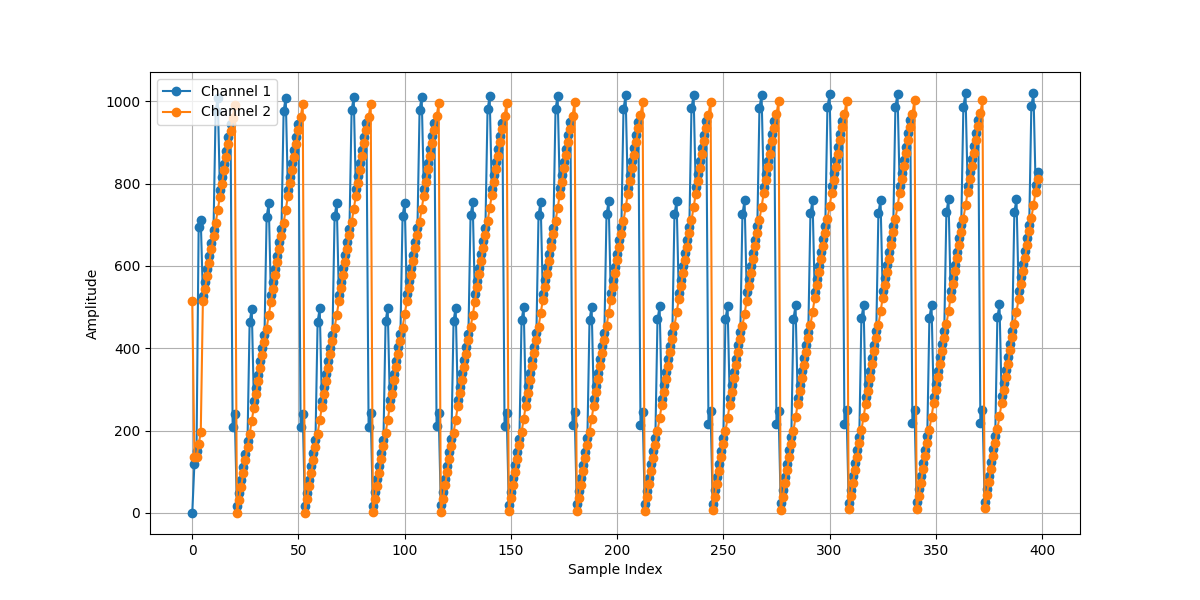

In [111]:
%matplotlib widget

plt.figure(figsize=(12, 6))

for i in range(rf_data_list.shape[1]):
    plt.plot(rf_data_list[5, i, :], 'o-', label=f'Channel {i+1}')

plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
# plt.xlim(0, 100)
plt.legend()
plt.grid()
plt.show()

In [104]:
# # Filter specifications
# f_sampling = 30e6 if config.fpga.afe_clk_hispeed else 10e6
# f_pass = [0.65*config.tx.pulse_freq_hz, 1.35*config.tx.pulse_freq_hz]
# f_stop = [0.65*config.tx.pulse_freq_hz-0.2e6, 1.35*config.tx.pulse_freq_hz+0.2e6]
# gpass = 1  # Maximum loss in the passband (dB)
# gstop = 60  # Minimum attenuation in the stopband (dB)

# # Normalize frequencies to the Nyquist frequency
# nyq = f_sampling / 2
# wp = np.array(f_pass) / nyq
# ws = np.array(f_stop) / nyq

# # Design the Chebyshev type II filter
# b, a = ss.iirfilter(N=5, Wn=wp, rs=gstop, btype='band', analog=False, ftype='cheby2', output='ba')

# numpy_arr_filt = ss.filtfilt(b, a, rf_data_list)

# numpy_arr_filt.shape # (num_shots, num_channels, num_samples)

In [105]:
# numpy_arr_filt *= 10

# plt.figure(figsize=(12, 6))

# for i in range(numpy_arr_filt.shape[1]):
#     plt.plot(numpy_arr_filt[5, i, :] / 100 + i, label=f'Channel {i+1}')

# # plt.imshow(numpy_arr_filt[:, 0, :], aspect='auto', interpolation='none')

# plt.title("Filtered RF Data")
# plt.xlabel("Sample Index")
# plt.ylabel("Amplitude")
# plt.grid()
# plt.show()

In [106]:
# from src.pybf.pybf.image_settings import ImageSettings

# image_x_range = [-0.04, 0.04]
# image_z_range = [0.0, 0.08]

# img_res = [600, 600]

# db_range = 40

# LATERAL_PIXEL_DENSITY_DEFAULT = 5

# trans = Transducer(
#     num_of_x_elements=config.tx.num_elems,
#     x_pitch=config.tx.pitch_m,
#     f_central_hz=config.tx.pulse_freq_hz,
#     bandwidth_hz=config.tx.pulse_freq_hz,
# )

# img_config = ImageSettings(
#     image_x_range[0],
#     image_x_range[1],
#     image_z_range[0],
#     image_z_range[1],
#     LATERAL_PIXEL_DENSITY_DEFAULT,
#     trans,
# )

In [107]:
# decimation_factor = 1
# interpolation_factor = 10
# alpha_fov_apod = 60

# # Low cutoff freq, high cutoff, transition band
# filters_params = None

# TX_START_DELAY_US = 5
# TR_SW_DELAY_US = 1.1

# TX_START_DELAY_US = TX_START_DELAY_US + TR_SW_DELAY_US

# start_time = -TX_START_DELAY_US * 1e-6
# correction_time_shift = 0.06 * 1e-6

# trans.set_active_elements([x for x in range(len(config.fpga.lvds_lanes) * 2)])

# bf = BFCartesianRealTime(
#     f_sampling,
#     config.tx.strategy.as_tuple(),
#     trans,
#     decimation_factor,
#     interpolation_factor,
#     img_res,
#     img_config,
#     db_range=db_range,
#     start_time=start_time,
#     correction_time_shift=correction_time_shift,
#     alpha_fov_apod=alpha_fov_apod,
#     bp_filter_params=filters_params
# )

In [108]:
# from tqdm import trange

# START_BEAMFORM = 0
# END_BEAMFORM = config.fpga.num_shots

# img_data = numpy_arr_filt.reshape((config.fpga.num_shots, config.tx.strategy.num_planewaves, rf_data_list.shape[1], rf_data_list.shape[2]))

# def parse_image(image_data):
#     return bf.beamform(image_data, core_type="numba")

# # Apply beamforming to each shot
# img_data = np.array([parse_image(img_data[i]) for i in trange(START_BEAMFORM, END_BEAMFORM, desc="Beamforming", unit="shot")])

In [109]:
# from ipywidgets import interact, IntSlider

# interact(
#     lambda frame: plot_image(
#         np.abs(img_data[frame]),
#         image_x_range=image_x_range,
#         image_z_range=image_z_range,
#         db_range=db_range,
#     ),
#     frame=IntSlider(min=0, max=img_data.shape[0]-1, step=1, value=0, continuous_update=False)
# )

In [110]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# FPS = 10

# plt.rcParams['animation.embed_limit'] = 50e6  # Increase limit to 50 MB

# frames, H, W = img_data.shape
# data = np.abs(img_data) + 1e-6  # avoid log(0)

# # build one image once (match your plot_image settings)
# fig, ax = plt.subplots()
# extent = [image_x_range[0], image_x_range[1], image_z_range[1], image_z_range[0]]  # z flipped if needed
# im = ax.imshow(
#     20*np.log10(data[0]),           # if your plot_image applies dB
#     extent=extent,
#     origin='upper',
#     aspect='auto',
#     vmin=20*np.log10(data[0]).max()-db_range, vmax=20*np.log10(data[0]).max(),
#     cmap='gray'
# )
# ax.set_xlabel('Lateral [m]')
# ax.set_ylabel('Axial [m]')

# def update(i):
#     im.set_data(20*np.log10(data[i]))
#     return (im,)

# print(f"Animation with {frames} frames of size {H}x{W} at {FPS} FPS")
# ani = FuncAnimation(fig, update, frames=frames, interval=1000/FPS, blit=True)
# print("Rendering animation...")
# HTML(ani.to_jshtml())  # renders inline without ffmpeg